In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics   import pairwise_distances, silhouette_score
from sklearn.cluster   import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_raw=pd.read_csv(r"C:\Users\saura\Downloads\Traffic_Crash_Reports__CPD__20250420.csv",low_memory=False)
df_raw.head(10)

,ADDRESS_X,LATITUDE_X,LONGITUDE_X,AGE,COMMUNITY_COUNCIL_NEIGHBORHOOD,CPD_NEIGHBORHOOD,SNA_NEIGHBORHOOD,CRASHDATE,CRASHLOCATION,CRASHSEVERITY,...,MANNEROFCRASH,ROADCONDITIONSPRIMARY,ROADCONTOUR,ROADSURFACE,ROADCLASS,ROADCLASSDESC,UNITTYPE,TYPEOFPERSON,WEATHER,ZIP
0,29XX GLENWAY,39.113959,-84.558828,53,EAST PRICE HILL,EAST PRICE HILL,EAST PRICE HILL,04/19/2025 12:10:00 AM,NaN,3 - MINOR INJURY SUSPECTED,...,"8 - SIDESWIPE, OPPOSITE DIRECTION",01 - DRY,4 - CURVE GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,02 - PASSENGER VAN (MINIVAN),D - DRIVER,1 - CLEAR,45204
1,42XX RED BANK EX,39.155091,-84.406071,34,MADISONVILLE,MADISONVILLE,MADISONVILLE,04/18/2025 10:40:00 PM,NaN,3 - MINOR INJURY SUSPECTED,...,6 - ANGLE,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,03 - SPORT UTILITY VEHICLE,D - DRIVER,1 - CLEAR,45227
2,42XX RED BANK EX,39.155971,-84.404911,24,MADISONVILLE,MADISONVILLE,MADISONVILLE,04/18/2025 10:40:00 PM,NaN,3 - MINOR INJURY SUSPECTED,...,6 - ANGLE,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,01 - PASSENGER CAR,D - DRIVER,1 - CLEAR,45227
3,42XX RED BANK EX,39.154531,-84.406171,39,MADISONVILLE,MADISONVILLE,MADISONVILLE,04/18/2025 10:40:00 PM,NaN,3 - MINOR INJURY SUSPECTED,...,6 - ANGLE,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,03 - SPORT UTILITY VEHICLE,O - OCCUPANT,1 - CLEAR,45227
4,22XX BANNING RD,39.202911,-84.563929,27,COLLEGE HILL,MOUNT AIRY,MT. AIRY,04/18/2025 10:02:00 PM,NaN,3 - MINOR INJURY SUSPECTED,...,6 - ANGLE,01 - DRY,4 - CURVE GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",3.0,Minor Arterial Roads,01 - PASSENGER CAR,D - DRIVER,1 - CLEAR,45239
5,22XX BANNING RD,39.203751,-84.565169,35,COLLEGE HILL,MOUNT AIRY,MT. AIRY,04/18/2025 10:02:00 PM,NaN,3 - MINOR INJURY SUSPECTED,...,6 - ANGLE,01 - DRY,4 - CURVE GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",3.0,Minor Arterial Roads,01 - PASSENGER CAR,D - DRIVER,1 - CLEAR,45239
6,22XX BANNING RD,39.203311,-84.564029,NaN,COLLEGE HILL,MOUNT AIRY,MT. AIRY,04/18/2025 10:02:00 PM,NaN,3 - MINOR INJURY SUSPECTED,...,6 - ANGLE,01 - DRY,4 - CURVE GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",3.0,Minor Arterial Roads,01 - PASSENGER CAR,O - OCCUPANT,1 - CLEAR,45239
7,36XX EDWARDS RD,39.163183,-84.427790,24,OAKLEY,OAKLEY,OAKLEY,04/18/2025 09:40:00 PM,NaN,5 - PROPERTY DAMAGE ONLY,...,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,01 - PASSENGER CAR,D - DRIVER,1 - CLEAR,45208
8,36XX EDWARDS RD,39.162633,-84.427870,16,OAKLEY,OAKLEY,OAKLEY,04/18/2025 09:40:00 PM,NaN,5 - PROPERTY DAMAGE ONLY,...,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,01 - PASSENGER CAR,D - DRIVER,1 - CLEAR,45208
9,47XX WINTON RD,39.177083,-84.519860,41,SPRING GROVE VILLAGE,SPRING GROVE VILLAGE,SPRING GROVE VILLAGE,04/18/2025 09:11:00 PM,NaN,5 - PROPERTY DAMAGE ONLY,...,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",NaN,NaN,04 - PICK UP,D - DRIVER,1 - CLEAR,45232


In [3]:
df = df_raw.copy()
df.columns = [c.strip().upper() for c in df.columns]          # normalise headers


date_col = "CRASHDATE"
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

numeric_cols = ["AGE", "INJURIES", "POSTED_SPEED_LIMIT"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


req_cols = [c for c in ["LATITUDE_X", "LONGITUDE_X", "POSTED_SPEED_LIMIT"] if c in df.columns]
df_clean = df.dropna(subset=req_cols).reset_index(drop=True)

print("Rows after basic NA drop:", df_clean.shape[0])
df.dtypes

Rows after basic NA drop: 392949


ADDRESS_X                                 object
LATITUDE_X                               float64
LONGITUDE_X                              float64
AGE                                      float64
COMMUNITY_COUNCIL_NEIGHBORHOOD            object
CPD_NEIGHBORHOOD                          object
SNA_NEIGHBORHOOD                          object
CRASHDATE                         datetime64[ns]
CRASHLOCATION                             object
CRASHSEVERITY                             object
CRASHSEVERITYID                          float64
DATECRASHREPORTED                         object
DAYOFWEEK                                 object
GENDER                                    object
INJURIES                                 float64
INSTANCEID                                object
LIGHTCONDITIONSPRIMARY                    object
LOCALREPORTNO                              int64
MANNEROFCRASH                             object
ROADCONDITIONSPRIMARY                     object
ROADCONTOUR         

In [4]:
def tukey_fences(series: pd.Series, k: float = 1.5):
    """Return (low_fence, high_fence) using Tukey’s IQR rule on non‑NaN data."""
    q1, q3 = series.dropna().quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr



lo_age, hi_age = tukey_fences(df_clean["AGE"])


age_mask = (df_clean["AGE"] < lo_age) | (df_clean["AGE"] > hi_age)
age_mask = age_mask.fillna(False)        # NaNs → False so mask length matches


outliers_age = df_clean[age_mask]


removed_age = outliers_age[(outliers_age["AGE"] < 0) | (outliers_age["AGE"] > 100)]
kept_age    = outliers_age.drop(index=removed_age.index)

print(f"\nTotal AGE analysed  : {df_clean['AGE'].notna().sum():,}")
print(f"Outliers (IQR rule) : {outliers_age.shape[0]:,}")
print(f"  • kept  (0–100)   : {kept_age.shape[0]:,}")
print(f"  • removed (<0|>100): {removed_age.shape[0]:,}")


df_final = df_clean.drop(index=removed_age.index).reset_index(drop=True)


Total AGE analysed  : 343,421
Outliers (IQR rule) : 853
  • kept  (0–100)   : 805
  • removed (<0|>100): 48


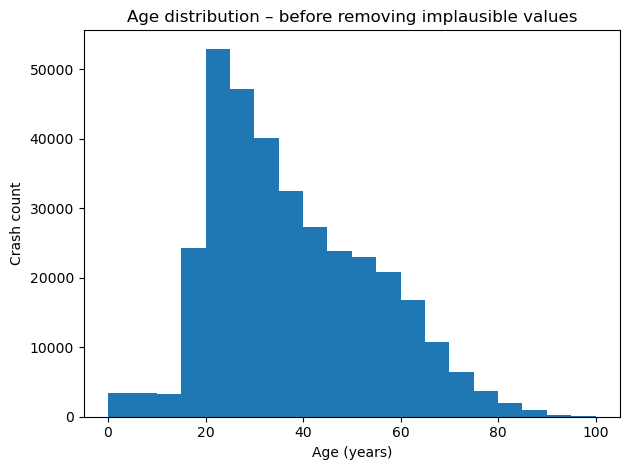

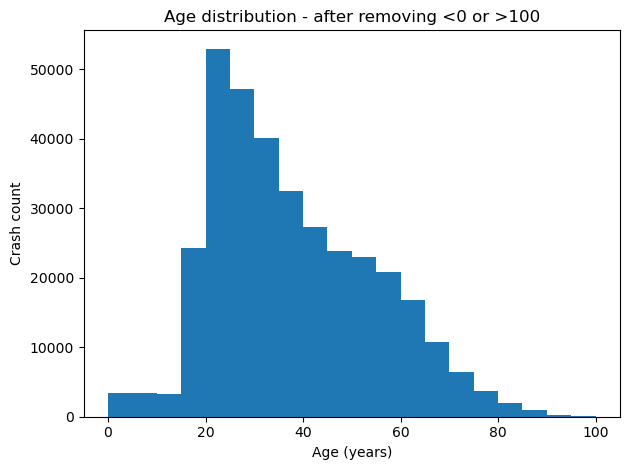

In [5]:
fig, ax = plt.subplots()
ax.hist(df_clean["AGE"].dropna(), bins=range(0, 105, 5))
ax.set(title="Age distribution – before removing implausible values",
       xlabel="Age (years)", ylabel="Crash count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.hist(df_final["AGE"].dropna(), bins=range(0, 105, 5))
ax.set(title="Age distribution ‑ after removing <0 or >100",
       xlabel="Age (years)", ylabel="Crash count")
plt.tight_layout()
plt.show()

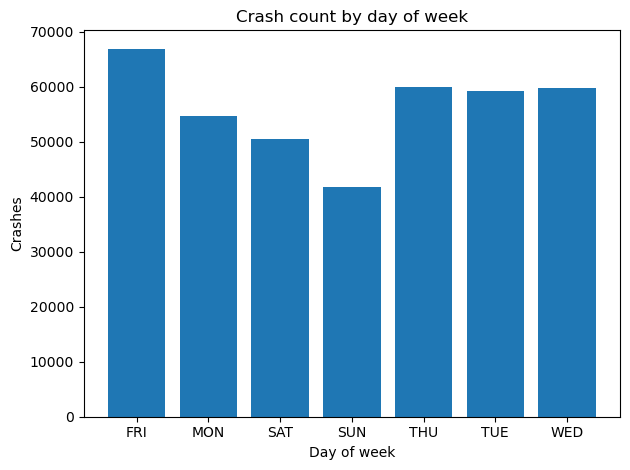

In [6]:
plt.figure()
day_counts = df["DAYOFWEEK"].value_counts().sort_index()
plt.bar(day_counts.index, day_counts.values)
plt.title("Crash count by day of week")
plt.xlabel("Day of week" + (" (0=Sun)" if day_counts.index.dtype.kind in "biu" else ""))
plt.ylabel("Crashes")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

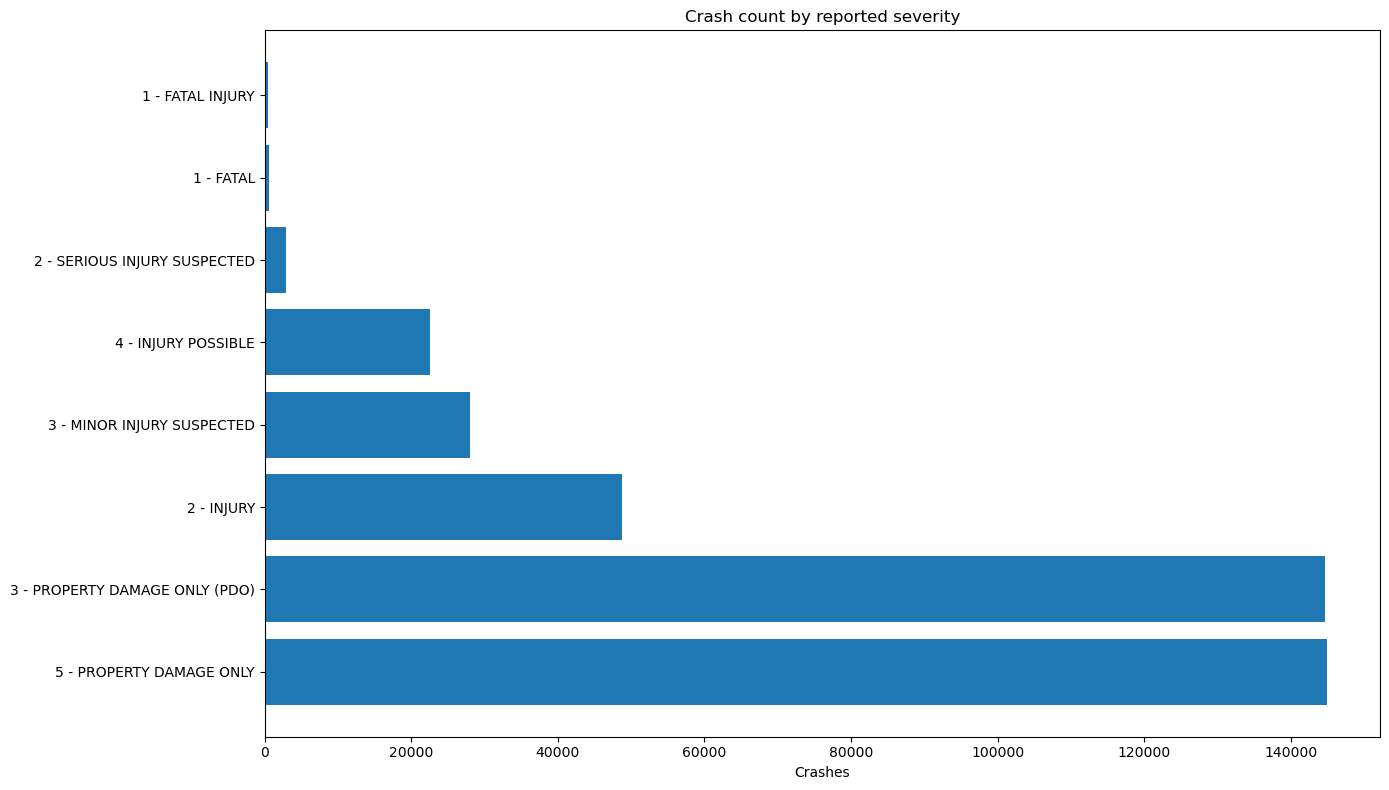

In [7]:
plt.figure()
plt.figure(figsize=(14, 8))
sev_counts = df["CRASHSEVERITY"].value_counts()
plt.barh(sev_counts.index, sev_counts.values)
plt.title("Crash count by reported severity")
plt.xlabel("Crashes")
plt.tight_layout()
plt.show()

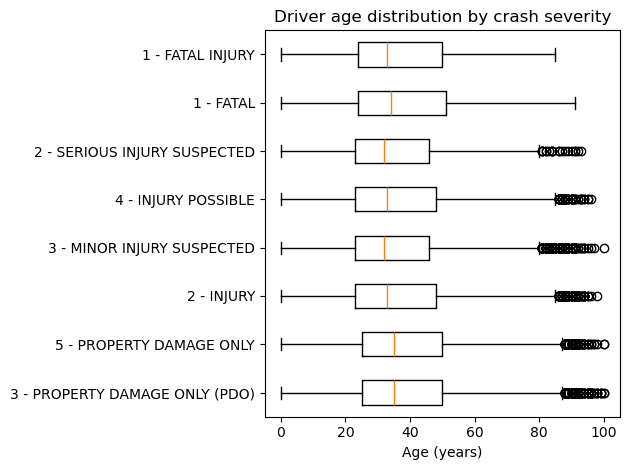

In [8]:
if "AGE" in df.columns:
    age_df = df[(df["AGE"].between(0, 100)) & df["AGE"].notna()]
    order = age_df["CRASHSEVERITY"].value_counts().index.tolist()
    box_data = [
        age_df.loc[age_df["CRASHSEVERITY"] == sev, "AGE"]
        for sev in order
    ]
    plt.figure()
    plt.boxplot(box_data, labels=order, vert=False)
    plt.title("Driver age distribution by crash severity")
    plt.xlabel("Age (years)")
    plt.tight_layout()
    plt.show()

In [9]:
df["INJURY_FLAG"] = (
    df["CRASHSEVERITY"].str.contains("INJURY", case=False, na=False)
    & ~df["CRASHSEVERITY"].str.contains("PROPERTY DAMAGE", case=False, na=False)
).astype(int)

In [10]:
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")
if df["DAYOFWEEK"].dtype == "object":               
    day_map = {"SUN":0,"MON":1,"TUE":2,"WED":3,"THU":4,"FRI":5,"SAT":6}
    df["DAYOFWEEK"] = df["DAYOFWEEK"].str[:3].str.upper().map(day_map)

df = df.dropna(subset=["AGE", "DAYOFWEEK"])         
X = df[["AGE", "DAYOFWEEK"]].values
y = df["INJURY_FLAG"].values

In [46]:
X_temp, X_exp, y_temp, y_exp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)                                                       # 0.25 of 0.80 = 0.20

print(f"Samples → train {len(X_train)}  |  test {len(X_test)}  |  exploratory {len(X_exp)}")


Samples → train 180297  |  test 60099  |  exploratory 103027


In [48]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)
X_exp_std   = scaler.transform(X_exp)

logreg = LogisticRegression(max_iter=1000, solver="lbfgs")
logreg.fit(X_train_std, y_train)

LogisticRegression(max_iter=1000)

In [50]:
intercept_std  = logreg.intercept_[0]
coef_age_std, coef_day_std = logreg.coef_[0]

# reverse scaling so we can show the human‑readable formula
age_std  = scaler.scale_[0];   age_mean  = scaler.mean_[0]
day_std  = scaler.scale_[1];   day_mean  = scaler.mean_[1]

coef_age = coef_age_std / age_std
coef_day = coef_day_std / day_std
intercept = (
    intercept_std
    - coef_age * age_mean
    - coef_day * day_mean
)

print("\nLogistic‑regression formula:")
print(f"  logit(P(Injury)) = {intercept:.4f}"
      f" + {coef_age:.4f} × AGE"
      f" + {coef_day:.4f} × DAYOFWEEK  + ε")


Logistic‑regression formula:
  logit(P(Injury)) = -0.5717 + -0.0091 × AGE + -0.0055 × DAYOFWEEK  + ε


In [52]:
y_test_prob = logreg.predict_proba(X_test_std)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("\nTest‑set performance")
print(f"  Accuracy  : {accuracy_score(y_test, y_test_pred):.3f}")
print(f"  ROC AUC   : {roc_auc_score(y_test, y_test_prob):.3f}")
print(classification_report(y_test, y_test_pred, digits=3))


Test‑set performance
  Accuracy  : 0.716
  ROC AUC   : 0.542
              precision    recall  f1-score   support

           0      0.716     1.000     0.835     43049
           1      0.000     0.000     0.000     17050

    accuracy                          0.716     60099
   macro avg      0.358     0.500     0.417     60099
weighted avg      0.513     0.716     0.598     60099



In [54]:
y_exp_prob = logreg.predict_proba(X_exp_std)[:, 1]
y_exp_pred = (y_exp_prob >= 0.5).astype(int)

explore_df = pd.DataFrame({
    "Actual"        : y_exp,
    "PredictedProb" : y_exp_prob,
    "Diff"          : y_exp_prob - y_exp
})
print("\nExploratory accuracy:", accuracy_score(y_exp, y_exp_pred).round(3))
print("Exploratory ROC AUC :", roc_auc_score(y_exp, y_exp_prob).round(3))


Exploratory accuracy: 0.716
Exploratory ROC AUC : 0.541



Predicted vs. Actual (sample):
 Actual  PredictedProb      Diff
      0       0.307398  0.307398
      0       0.227423  0.227423
      1       0.285057 -0.714943
      0       0.299709  0.299709
      0       0.297905  0.297905
      0       0.279145  0.279145
      0       0.197285  0.197285
      0       0.280303  0.280303
      0       0.305872  0.305872
      0       0.284277  0.284277
      0       0.318718  0.318718
      0       0.291735  0.291735
      0       0.308214  0.308214
      1       0.221425 -0.778575
      0       0.311283  0.311283
      0       0.289960  0.289960
      1       0.314061 -0.685939
      0       0.313648  0.313648
      0       0.219862  0.219862
      1       0.245119 -0.754881


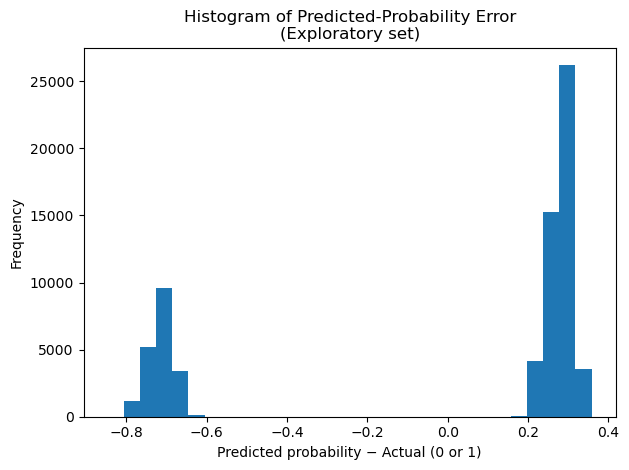

In [16]:
print("\nPredicted vs. Actual (sample):")
print(explore_df.head(20).to_string(index=False))

plt.figure()
plt.hist(explore_df["Diff"], bins=30)
plt.title("Histogram of Predicted‑Probability Error\n(Exploratory set)")
plt.xlabel("Predicted probability − Actual (0 or 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [17]:
clust_df = df_final.copy()                  # <‑‑ reuse your cleaned frame
clust_df["AGE"]      = pd.to_numeric(clust_df["AGE"],      errors="coerce")
clust_df["INJURIES"] = pd.to_numeric(clust_df["INJURIES"], errors="coerce")

clust_df["AGE"].fillna(clust_df["AGE"].median(), inplace=True)
clust_df["INJURIES"].fillna(0, inplace=True)

clust_df = clust_df.sample(n=min(2000, len(clust_df)), random_state=42)

scaler  = StandardScaler()
X_clust = scaler.fit_transform(clust_df[["AGE", "INJURIES"]])


Pairwise‑distance matrix (100 × 100 slice):
         0         1         2         3         4         5         6   \
0  0.000000  0.126357  0.505430  0.505430  1.010859  0.505430  1.074038   
1  0.126357  0.000000  0.379072  0.379072  1.137217  0.631787  0.947681   
2  0.505430  0.379072  0.000000  0.000000  1.516289  1.010859  0.568608   
3  0.505430  0.379072  0.000000  0.000000  1.516289  1.010859  0.568608   
4  1.010859  1.137217  1.516289  1.516289  0.000000  0.505430  2.084897   

         7         8         9   ...        90        91        92        93  \
0  0.505430  0.379072  2.463970  ...  1.453110  0.758144  0.758144  1.389932   
1  0.379072  0.252715  2.337612  ...  1.326753  0.631787  0.631787  1.263574   
2  0.000000  0.126357  1.958540  ...  0.947681  0.252715  0.252715  0.884502   
3  0.000000  0.126357  1.958540  ...  0.947681  0.252715  0.252715  0.884502   
4  1.516289  1.389932  3.474829  ...  2.463970  1.769004  1.769004  2.400791   

         94        95  

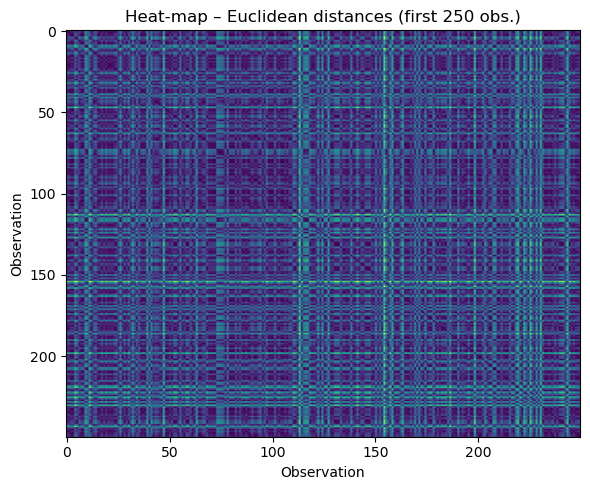

In [18]:
from sklearn.metrics import pairwise_distances
dist_100 = pairwise_distances(X_clust[:100])
print("\nPairwise‑distance matrix (100 × 100 slice):")
print(pd.DataFrame(dist_100).head())

plt.figure(figsize=(6,5))
plt.imshow(pairwise_distances(X_clust[:250]), aspect="auto", cmap="viridis")
plt.title("Heat‑map – Euclidean distances (first 250 obs.)")
plt.xlabel("Observation"); plt.ylabel("Observation")
plt.tight_layout(); plt.show()

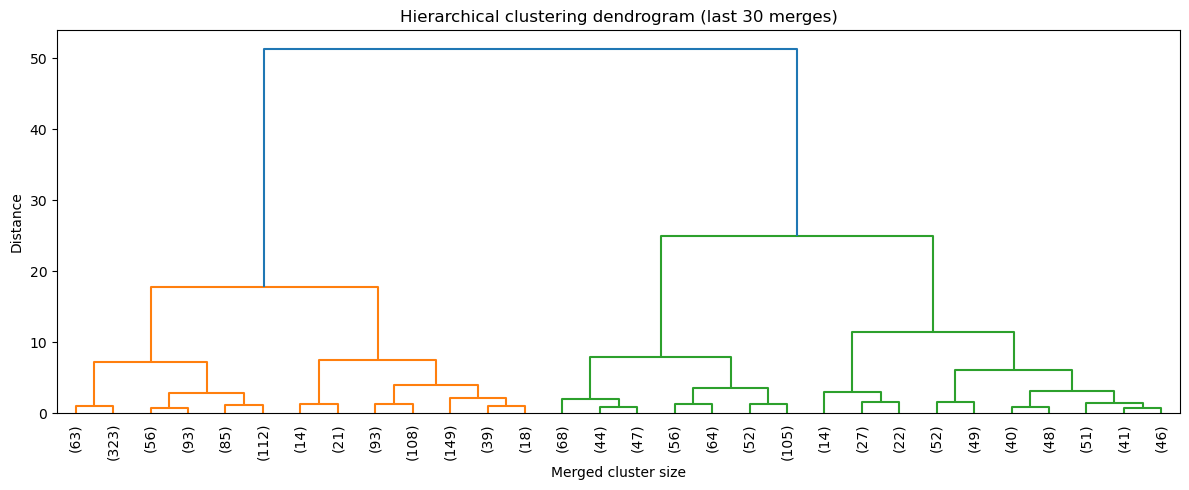

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_clust, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90.)
plt.title("Hierarchical clustering dendrogram (last 30 merges)")
plt.xlabel("Merged cluster size"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

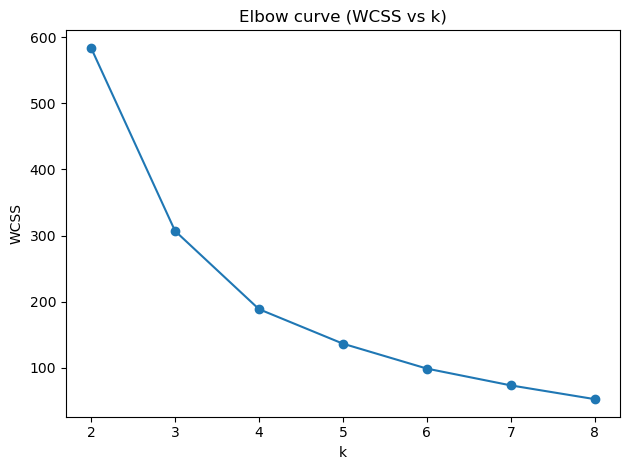

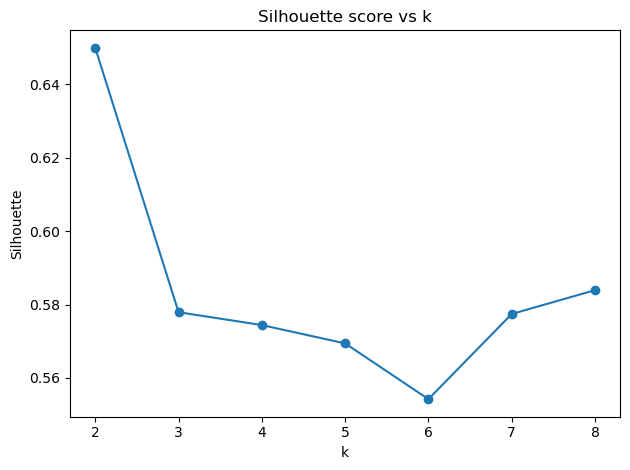


Chosen k = 2  (silhouette = 0.650)

Cluster membership:
  Cluster 0: 1405 members
  Cluster 1: 595 members


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range, inertias, silh = [], [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_clust)
    k_range.append(k)
    inertias.append(km.inertia_)
    silh.append(silhouette_score(X_clust, labels))

plt.figure(); plt.plot(k_range, inertias, marker="o")
plt.title("Elbow curve (WCSS vs k)"); plt.xlabel("k"); plt.ylabel("WCSS")
plt.tight_layout(); plt.show()

plt.figure(); plt.plot(k_range, silh, marker="o")
plt.title("Silhouette score vs k"); plt.xlabel("k"); plt.ylabel("Silhouette")
plt.tight_layout(); plt.show()

best_k = k_range[int(np.argmax(silh))]      # highest silhouette
print(f"\nChosen k = {best_k}  (silhouette = {max(silh):.3f})")

kmeans   = KMeans(n_clusters=best_k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_clust)

cluster_ids, counts = np.unique(clusters, return_counts=True)
print("\nCluster membership:")
for cid, ct in zip(cluster_ids, counts):
    print(f"  Cluster {cid}: {ct} members")

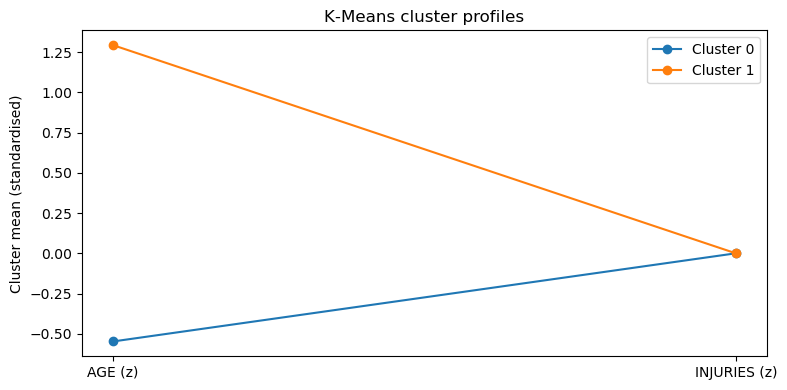

In [21]:
plt.figure(figsize=(8,4))
for cid in cluster_ids:
    mean_profile = X_clust[clusters == cid].mean(axis=0)
    plt.plot(mean_profile, marker="o", label=f"Cluster {cid}")
plt.xticks([0,1], ["AGE (z)", "INJURIES (z)"])
plt.ylabel("Cluster mean (standardised)")
plt.title("K‑Means cluster profiles")
plt.legend(); plt.tight_layout(); plt.show()